- Title: DSC 540 Assignment for Week 5 & 6 
- Author: Rethish Plappuzha Sreedharan Nair
- Date: 10-14-2025
- Description: This program demonstrates the use of basic data wrangling techniques

In [41]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import requests
import sqlite3

# The Data Wrangling Workshop: Activity 5.01

## Execise 2 
Read the page (https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)) using bs4.

In [42]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {
    'User-Agent': 'DSC540_Rethish_week_5_6/1.0'
    }

wiki = BeautifulSoup(requests.get(url, headers=headers).text, "html.parser")    

## Execise 3
Find the table structure you will need to deal with (how many tables are there?).

In [43]:
# FInding all the tables in the webpage
tables =  wiki.find_all('table')
print('Total Tables : ',len(tables))

Total Tables :  7


## Exercise 4
Find the right table using bs4.

In [44]:
# Finding all the tables with class 'wikitable' as that is the class for the table we need to extract
wiki_table = wiki.find_all('table', class_='wikitable') 
print('Total Wiki Tables for the requirement : ',len(wiki_table))

Total Wiki Tables for the requirement :  1


## Exercise 5
Separate the source names and their corresponding data.

In [45]:
# Extracting the first table with class 'wikitable' as that is the table we need to extract

data_table = wiki.find("table",class_='wikitable')
# getting the header row and data rows separately
header_row = data_table.find_all('th')
data_rows = data_table.find_all('tr')[1:]

# Extracting the text from the header row and data rows
headers = [ header.get_text(strip=True) for header in header_row ]

data = [ [td.get_text(strip=True) for td in row.find_all('td')] for row in data_rows ]

# Separating the country names and their corresponding data
coutries = [ d[0] for d in data ]

# Seperating the data corresponding to each country
coutries_data = [ d[1:] for d in data ]
coutries_data

print("Headers:", headers)
print("Countries:", coutries)
print("Countries Data:", coutries_data)

Headers: ['Country/Territory', 'IMF(2025)[1][6]', 'World Bank(2022–24)[7]', 'United Nations(2023)[8]']
Countries: ['World', 'United States', 'China[n 1]', 'Germany', 'Japan', 'India', 'United Kingdom', 'France', 'Italy', 'Russia', 'Canada', 'Brazil', 'Spain', 'Mexico', 'South Korea', 'Australia', 'Turkey', 'Indonesia', 'Netherlands', 'Saudi Arabia', 'Poland', 'Switzerland', 'Taiwan[n 3]', 'Belgium', 'Ireland', 'Argentina', 'Sweden', 'Israel', 'Singapore', 'United Arab Emirates', 'Thailand', 'Austria', 'Norway', 'Philippines', 'Vietnam', 'Bangladesh', 'Denmark', 'Malaysia', 'Colombia', 'Hong Kong[n 4]', 'South Africa', 'Romania', 'Pakistan', 'Czech Republic', 'Egypt', 'Chile', 'Iran', 'Portugal', 'Finland', 'Peru', 'Kazakhstan', 'Algeria', 'Greece', 'Iraq', 'New Zealand', 'Hungary', 'Qatar', 'Ukraine[n 5]', 'Cuba', 'Nigeria', 'Morocco', 'Kuwait', 'Slovakia', 'Uzbekistan', 'Kenya', 'Dominican Republic', 'Ecuador', 'Puerto Rico', 'Guatemala', 'Ethiopia', 'Bulgaria', 'Angola', 'Venezuela',

## Exercise 6
Get the source names from the list of sources you have created.

In [46]:

source_names =[ header_row[i].find('a').getText() for i in range(1,len(header_row))  ]
print("Source Names:", source_names)

Source Names: ['IMF', 'World Bank', 'United Nations']


## Exercise 7
Separate the header and data from the data that you separated before for the first source only, and then create a DataFrame using that.

In [47]:
data[:5]

[['World', '117,165,394', '111,326,370', '100,834,796'],
 ['United States', '30,615,743', '29,184,890', '27,720,700'],
 ['China[n 1]', '19,398,577', '18,743,803', '17,794,782'],
 ['Germany', '5,013,574', '4,659,929', '4,525,704'],
 ['Japan', '4,279,828', '4,026,211', '4,204,495']]

In [48]:
#[d[:2] for d in data]
df_gdp1 = pd.DataFrame([d[:2] for d in data], columns=headers[:2])
# Creating Rank column, with empty string for First row
df_gdp1['Rank'] = [ a if a!=0  else "" for a in range(df_gdp1.index.max()+1) ]
#df_gdp.index.rename('Rank', inplace=True)
df_gdp1[:10]

,Country/Territory,IMF(2025)[1][6],Rank
0,World,"117,165,394",
1,United States,"30,615,743",1
2,China[n 1],"19,398,577",2
3,Germany,"5,013,574",3
4,Japan,"4,279,828",4
5,India,"4,125,213",5
6,United Kingdom,"3,958,780",6
7,France,"3,361,557",7
8,Italy,"2,543,677",8
9,Russia,"2,540,656",9


## Exercise 8 
Repeat the last task for the other two data sources.

In [49]:
#[ [d[0],  d[2]] for d in data]

df_gdp2 = pd.DataFrame([ [d[0],  d[2]] for d in data ], columns=[ headers[0], headers[2] ] ) 
# Creating Rank column, with empty string for First row
df_gdp2['Rank'] = [ a if a!=0  else "" for a in range(df_gdp2.index.max()+1) ]
#df_gdp.index.rename('Rank', inplace=True)
df_gdp2[:10]

,Country/Territory,World Bank(2022–24)[7],Rank
0,World,"111,326,370",
1,United States,"29,184,890",1
2,China[n 1],"18,743,803",2
3,Germany,"4,659,929",3
4,Japan,"4,026,211",4
5,India,"3,912,686",5
6,United Kingdom,"3,643,834",6
7,France,"3,162,079",7
8,Italy,"2,372,775",8
9,Russia,"2,173,836",9


In [50]:
df_gdp3 = pd.DataFrame([ [d[0],  d[3]] for d in data ], columns=[ headers[0], headers[3] ] ) 

df_gdp3['Rank'] = [ a if a!=0  else "" for a in range(df_gdp3.index.max()+1) ]
#df_gdp.index.rename('Rank', inplace=True)
df_gdp3[:10]

,Country/Territory,United Nations(2023)[8],Rank
0,World,"100,834,796",
1,United States,"27,720,700",1
2,China[n 1],"17,794,782",2
3,Germany,"4,525,704",3
4,Japan,"4,204,495",4
5,India,"3,575,778",5
6,United Kingdom,"3,380,855",6
7,France,"3,051,832",7
8,Italy,"2,300,941",8
9,Russia,"2,008,419",9


# The Data Wrangling Workshop: Activity 6.01

## Exercise 1
Read the visit_data.csv file.

In [51]:
df_visits= pd.read_csv('./visit_data.csv')
df_visits[:10]

,id,first_name,last_name,email,gender,ip_address,visit
0,1,Sonny,Dahl,sdahl0@mysql.com,Male,135.36.96.183,1225.0
1,2,NaN,NaN,dhoovart1@hud.gov,NaN,237.165.194.143,919.0
2,3,Gar,Armal,garmal2@technorati.com,NaN,166.43.137.224,271.0
3,4,Chiarra,Nulty,cnulty3@newyorker.com,NaN,139.98.137.108,1002.0
4,5,NaN,NaN,sleaver4@elegantthemes.com,NaN,46.117.117.27,2434.0
5,6,Raymund,Ingerfield,ringerfield5@microsoft.com,NaN,90.100.118.215,451.0
6,7,Wilhelmina,Dagnan,wdagnan6@nytimes.com,Female,88.133.77.243,1540.0
7,8,NaN,NaN,mdewilde7@creativecommons.org,Female,229.215.244.227,537.0
8,9,Gunter,Lisamore,glisamore8@disqus.com,NaN,134.185.44.82,743.0
9,10,Luelle,Scinelli,lscinelli9@issuu.com,Female,160.130.58.61,1507.0


## Exercise 2
Check for duplicates.

In [52]:
print("Count of Duplicate IP Addresses : ", df_visits['ip_address'].duplicated().sum())
print("Count of Duplicate Email Addresses : ", df_visits['email'].duplicated().sum())

Count of Duplicate IP Addresses :  0
Count of Duplicate Email Addresses :  0


## Exercise 3
Check whether any essential column contains NaN.

In [53]:
# Check whether any essential column contains NaN.
df_visits.isna().sum()
# We can see First name, Last name, gender and visits columns have NaN values.

id              0
first_name    296
last_name     296
email           0
gender        505
ip_address      0
visit          26
dtype: int64

## Exercise 4
Get rid of the outliers.

In [54]:
size_prev = df_visits.shape

df_visits_new = df_visits[np.isfinite(df_visits['visit'])] 
# This is an inplace operation.
# After this operation the original DataFrame is lost.

# The visits column has no NaN values now. Previously it has 26 NaN values.
df_visits_new.isna().sum()


id              0
first_name    287
last_name     287
email           0
gender        493
ip_address      0
visit           0
dtype: int64

## Exercise 5
Report the size difference.

In [55]:
size_after = df_visits_new.shape
print("Previous Size : ", size_prev, " After removing outliers Size : ", size_after)

Previous Size :  (1000, 7)  After removing outliers Size :  (974, 7)


## Exercise 6
Create a box plot to check for outliers.

<Axes: title={'center': 'Box plot for Visits'}>

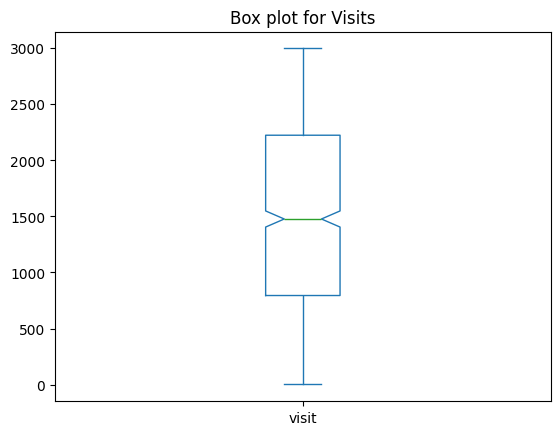

In [56]:
df_visits_new['visit'].plot.box(title='Box plot for Visits',notch=True)

## Exercise 7
Get rid of any outliers.

In [57]:
# Removing the outliers
# Keeping only the data within the 5th and 95th percentile
df_cleaned = df_visits_new[(df_visits_new['visit'] >= df_visits_new['visit'].quantile(0.05)) & (df_visits_new['visit'] <= df_visits_new['visit'].quantile(0.95))]
size_cleaned = df_cleaned.shape
print("After removing outliers Size : ", size_cleaned)

After removing outliers Size :  (877, 7)


# 3 Insert data into a SQL Lite database – 

## a. Create a table with the following data - 
Name, Address, City, State, Zip, Phone Number

In [58]:
create_table = """
create table IF NOT EXISTS person_info (
    Name TEXT,
    Address TEXT,
    City TEXT,
    State TEXT,
    Zip TEXT,
    Phone_Number TEXT
);
"""

conn = sqlite3.connect('person_info.db')
cursor = conn.cursor()
cursor.execute(create_table)
conn.commit()

## b. Add at least 10 rows of data and submit your code with a query generating your results.

In [59]:
insert_data = """
INSERT INTO person_info (Name, Address, City, State, Zip, Phone_Number) VALUES
(?, ?, ?, ?, ?, ?)
"""

data_to_insert = [
    ('Rethish Nair', '123 Main St', 'Green Valley', 'CO', '62701', '222-555-1234'),
    ('Joel Smith', '456 Oak St', 'Green Valley', 'IL', '62702', '222-555-5678'),
    ('Sachin T', '789 Pine St', 'Green Valley', 'NY', '62703', '222-555-8765'),
    ('Raj Mani', '321 Maple St', 'Green Valley', 'CA', '62704', '222-555-4321'),
    ('Sam Altman', '654 Cedar St', ' Green Valley', 'MN', '62705', '222-555-6789'),
    ('Jesse Pinkman', '987 Birch St', 'Green Valley', 'IL', '62706', '222-555-9876'),
    ('Walter White', '147 Elm St', 'Green Valley', 'IL', '62707', '222-555-3456'),
    ('Kate Harris      ', '258 Walnut St', 'Green Valley', 'IL', '62708', '222-555-6543'),
    ('Joseph King', '369 Chestnut St', 'Green Valley', 'IL', '62709', '222-555-7890'),
    ('Ivy Lee', '159 Spruce St', 'Green Valley', 'IL', '62710', '222-555-0987')
]

cursor.executemany(insert_data, data_to_insert)
conn.commit()

In [60]:
cursor.execute("SELECT * FROM person_info")
rows = cursor.fetchall()
for row in rows:
    print(row)      

('Rethish Nair', '123 Main St', 'Green Valley', 'CO', '62701', '222-555-1234')
('Joel Smith', '456 Oak St', 'Green Valley', 'IL', '62702', '222-555-5678')
('Sachin T', '789 Pine St', 'Green Valley', 'NY', '62703', '222-555-8765')
('Raj Mani', '321 Maple St', 'Green Valley', 'CA', '62704', '222-555-4321')
('Sam Altman', '654 Cedar St', ' Green Valley', 'MN', '62705', '222-555-6789')
('Jesse Pinkman', '987 Birch St', 'Green Valley', 'IL', '62706', '222-555-9876')
('Walter White', '147 Elm St', 'Green Valley', 'IL', '62707', '222-555-3456')
('Kate Harris      ', '258 Walnut St', 'Green Valley', 'IL', '62708', '222-555-6543')
('Joseph King', '369 Chestnut St', 'Green Valley', 'IL', '62709', '222-555-7890')
('Ivy Lee', '159 Spruce St', 'Green Valley', 'IL', '62710', '222-555-0987')
